In [ ]:
!pip install -q ultralytics
import ultralytics, torch
print('ultralytics:', ultralytics.__version__)
print('torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.4.48
torch: 2.10.0+cu128 | CUDA available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil, random, itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
import torch
from ultralytics import YOLO

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---- Paths & params ----
SOURCE_DIR       = '/content/drive/My Drive/CS471_AI/cs471_data'  # raw class folders
WORK_DIR         = '/content/yolo_dataset'                    # YOLO-formatted dataset
RUNS_DIR         = '/content/runs'

IMAGES_PER_CLASS = 200       # balance every class to this count
TRAIN_RATIO      = 0.70
VAL_RATIO        = 0.15
TEST_RATIO       = 0.15
IMG_SIZE         = 224
BATCH            = 32
TUNE_EPOCHS      = 15        # epochs per tuning run
FINAL_EPOCHS     = 30        # epochs for the final model

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9
print('Source dir contents:', os.listdir(SOURCE_DIR))

Source dir contents: ['dogs', 'coyote', 'humans', 'raccoon']


Detected 4 classes: ['coyote', 'dogs', 'humans', 'raccoon']
Raw class counts: {'coyote': 736, 'dogs': 202, 'humans': 202, 'raccoon': 724}


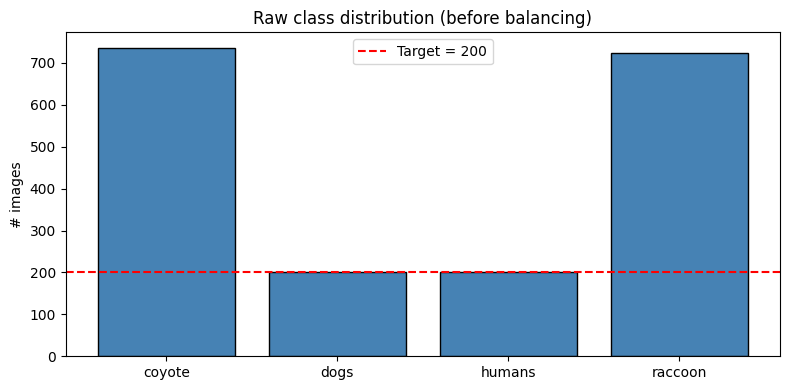

In [ ]:
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

CLASSES = sorted([d for d in os.listdir(SOURCE_DIR)
                  if os.path.isdir(os.path.join(SOURCE_DIR, d))])
print(f'Detected {len(CLASSES)} classes: {CLASSES}')

raw_counts = {}
class_files = {}
for c in CLASSES:
    files = [f for f in os.listdir(os.path.join(SOURCE_DIR, c))
             if f.lower().endswith(IMG_EXTS)]
    raw_counts[c] = len(files)
    class_files[c] = files

print('Raw class counts:', raw_counts)

plt.figure(figsize=(8, 4))
plt.bar(raw_counts.keys(), raw_counts.values(), color='steelblue', edgecolor='black')
plt.axhline(IMAGES_PER_CLASS, color='red', linestyle='--',
            label=f'Target = {IMAGES_PER_CLASS}')
plt.title('Raw class distribution (before balancing)')
plt.ylabel('# images'); plt.legend(); plt.tight_layout(); plt.show()

Balanced total: 800 samples
Counts after balancing: Counter({'coyote': 200, 'dogs': 200, 'humans': 200, 'raccoon': 200})


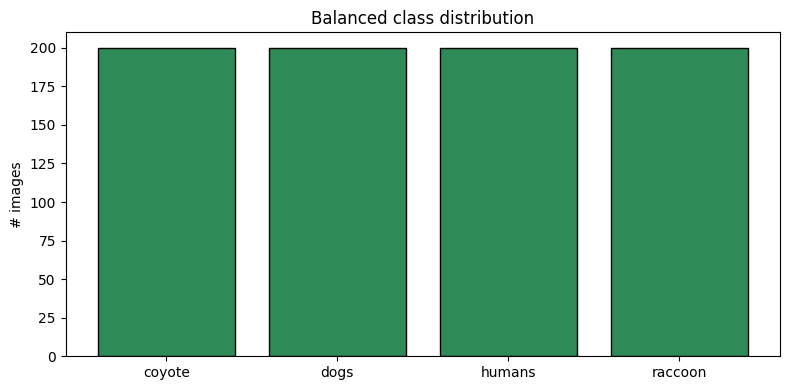

In [ ]:
# Build a balanced (file, label) list
all_files, all_labels = [], []
for c in CLASSES:
    files = class_files[c][:]
    random.shuffle(files)
    if len(files) >= IMAGES_PER_CLASS:
        chosen = files[:IMAGES_PER_CLASS]
    else:
        print(f'  WARN: {c} has {len(files)} images; oversampling with replacement.')
        chosen = files + random.choices(files, k=IMAGES_PER_CLASS - len(files))
    for f in chosen:
        all_files.append(os.path.join(SOURCE_DIR, c, f))
        all_labels.append(c)

print(f'Balanced total: {len(all_files)} samples')
print('Counts after balancing:', Counter(all_labels))

# Plot balanced distribution
balanced = Counter(all_labels)
plt.figure(figsize=(8, 4))
plt.bar(balanced.keys(), balanced.values(), color='seagreen', edgecolor='black')
plt.title('Balanced class distribution')
plt.ylabel('# images'); plt.tight_layout(); plt.show()

Train:  559   Val:  120   Test:  121
Train counts: {'humans': 139, 'raccoon': 140, 'dogs': 140, 'coyote': 140}
Val counts:   {'coyote': 30, 'raccoon': 30, 'humans': 30, 'dogs': 30}
Test counts:  {'humans': 31, 'dogs': 30, 'raccoon': 30, 'coyote': 30}


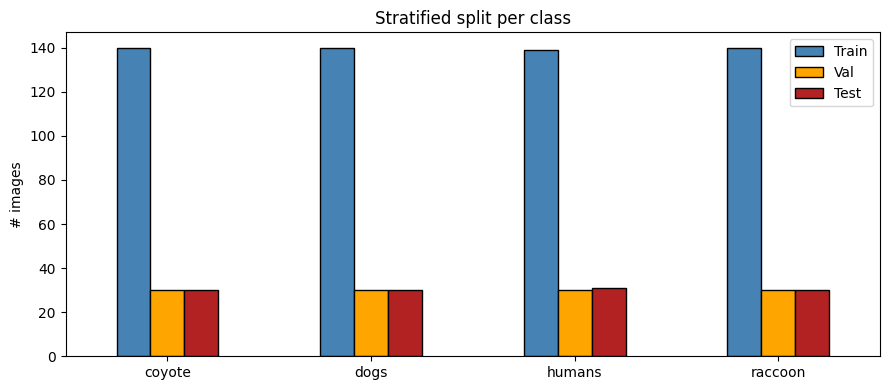

In [ ]:
# Step 1: split off train (70%); keep 30% as a temp pool
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, all_labels,
    test_size=(1 - TRAIN_RATIO),
    stratify=all_labels,
    random_state=SEED,
)
# Step 2: split temp 50/50 → val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=y_temp,
    random_state=SEED,
)

print(f'Train: {len(X_train):4d}   Val: {len(X_val):4d}   Test: {len(X_test):4d}')
print('Train counts:', dict(Counter(y_train)))
print('Val counts:  ', dict(Counter(y_val)))
print('Test counts: ', dict(Counter(y_test)))

# Visualize the split
split_df = pd.DataFrame({
    'Train': [Counter(y_train)[c] for c in CLASSES],
    'Val':   [Counter(y_val)[c]   for c in CLASSES],
    'Test':  [Counter(y_test)[c]  for c in CLASSES],
}, index=CLASSES)
split_df.plot(kind='bar', figsize=(9, 4),
              color=['steelblue', 'orange', 'firebrick'], edgecolor='black')
plt.title('Stratified split per class'); plt.ylabel('# images')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [ ]:
import os
import shutil
from ultralytics import YOLO
import pandas as pd

# Prepare the YOLO directory structure
print("Copying images into YOLO dataset structure...")
for split, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    for img_path, label in zip(X, y):
        dest_dir = os.path.join(WORK_DIR, split, label)
        os.makedirs(dest_dir, exist_ok=True)
        dest_file = os.path.join(dest_dir, os.path.basename(img_path))
        if not os.path.exists(dest_file):
            try:
                shutil.copy(img_path, dest_file)
            except Exception as e:
                pass
print("Dataset preparation complete.")

epoch_values = [5, 10, 15]
epoch_results = []

for epochs in epoch_values:
    print(f"\n--- Training for {epochs} epochs ---")
    # Load a fresh pre-trained model for each run to ensure fair comparison
    model = YOLO('yolo11n-cls.pt')

    # Train the model
    results = model.train(
        data=WORK_DIR,
        epochs=epochs,
        imgsz=IMG_SIZE,
        batch=BATCH,
        project=RUNS_DIR,
        name=f'tune_epochs_{epochs}',
        device=0
    )

    # Record the validation metrics
    epoch_results.append({
        'epochs': epochs,
        'val_top1_acc': results.top1,
        'val_top5_acc': results.top5
    })

# Report the collected metrics
metrics_df = pd.DataFrame(epoch_results)
print("\n--- Epoch Tuning Results ---")
print(metrics_df.to_string(index=False))


Copying images into YOLO dataset structure...
Dataset preparation complete.

--- Training for 5 epochs ---
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=


--- Tuning: 10 epochs | lr0=0.01 ---
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tune_ep10_lr0.01, nbs=64, nms=False, opset=None, optimize=

,epochs,lr0,val_top1_acc,val_top5_acc
0,10,0.0100,0.975,1.0
1,10,0.0010,0.975,1.0
2,10,0.0001,0.975,1.0


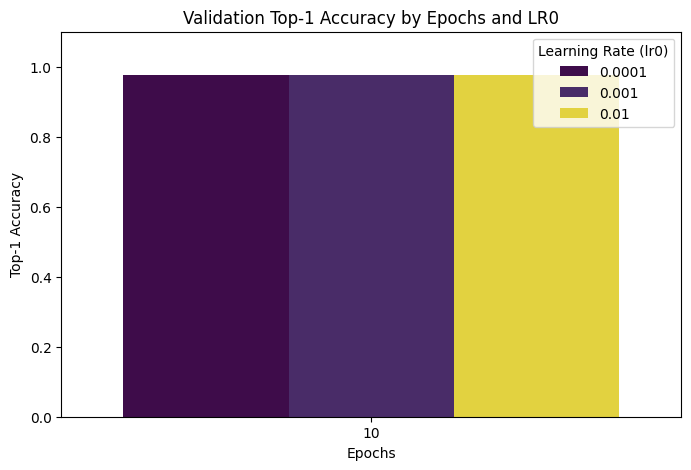

In [ ]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tune two hyperparameters: epochs and lr0
epoch_values = [10]
lr0_values = [0.01, 0.001, 0.0001]
tune_results = []

for epochs in epoch_values:
    for lr0 in lr0_values:
        print(f"\n--- Tuning: {epochs} epochs | lr0={lr0} ---")
        # Load a fresh pre-trained model for each run
        model = YOLO('yolo11n-cls.pt')

        # Train the model
        results = model.train(
            data=WORK_DIR,
            epochs=epochs,
            lr0=lr0,
            imgsz=IMG_SIZE,
            batch=BATCH,
            project=RUNS_DIR,
            name=f'tune_ep{epochs}_lr{lr0}',
            device=0
        )

        # Record the validation metrics
        tune_results.append({
            'epochs': epochs,
            'lr0': lr0,
            'val_top1_acc': results.top1,
            'val_top5_acc': results.top5
        })

# Report the collected metrics
metrics_df = pd.DataFrame(tune_results)
print("\n--- Epoch & LR0 Tuning Results ---")
display(metrics_df)

# Plot the tuning results
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x='epochs', y='val_top1_acc', hue='lr0', palette='viridis')
plt.title('Validation Top-1 Accuracy by Epochs and LR0')
plt.ylabel('Top-1 Accuracy')
plt.xlabel('Epochs')
plt.ylim(0, 1.1)
plt.legend(title='Learning Rate (lr0)')
plt.show()


In [ ]:
import glob
import os
from ultralytics import YOLO
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Find the latest training run directory containing 'weights/best.pt'
run_dirs = glob.glob(os.path.join(RUNS_DIR, '*', 'weights', 'best.pt'))
if not run_dirs:
    raise FileNotFoundError("No 'best.pt' model found in the runs directory. Please complete a training run first.")

best_model_path = max(run_dirs, key=os.path.getmtime)
print(f"Loading best model from: {best_model_path}")
best_model = YOLO(best_model_path)

# Run predictions on the test dataset
print("Running inference on the test set...")
predictions = best_model.predict(X_test, verbose=False)

# Extract the predicted class names
y_pred = [best_model.names[p.probs.top1] for p in predictions]

# Calculate and print the metrics
print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_pred))

# Calculate explicit macro averages
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nMacro Precision: {macro_precision:.4f}")
print(f"Macro Recall:    {macro_recall:.4f}")
print(f"Macro F1-Score:  {macro_f1:.4f}")


Loading best model from: /content/runs/tune_ep10_lr0.0001/weights/best.pt
Running inference on the test set...

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

      coyote       0.97      1.00      0.98        30
        dogs       1.00      0.97      0.98        30
      humans       1.00      1.00      1.00        31
     raccoon       0.97      0.97      0.97        30

    accuracy                           0.98       121
   macro avg       0.98      0.98      0.98       121
weighted avg       0.98      0.98      0.98       121


Macro Precision: 0.9836
Macro Recall:    0.9833
Macro F1-Score:  0.9833


--- Training Final Model ---
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_model, nbs=64, nms=False, opset=None, optimize=False, optimiz

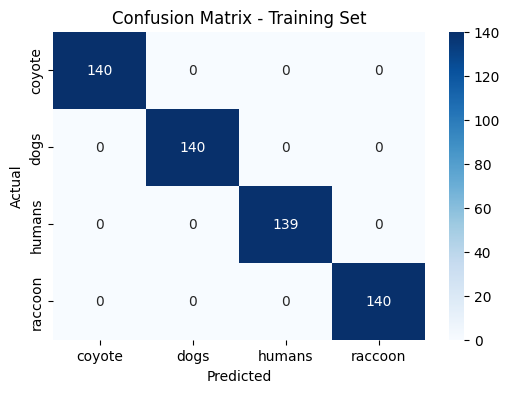


--- Evaluating on Testing Set ---

Classification Report (Testing):
              precision    recall  f1-score   support

      coyote       0.88      1.00      0.94        30
        dogs       1.00      0.93      0.97        30
      humans       1.00      1.00      1.00        31
     raccoon       1.00      0.93      0.97        30

    accuracy                           0.97       121
   macro avg       0.97      0.97      0.97       121
weighted avg       0.97      0.97      0.97       121



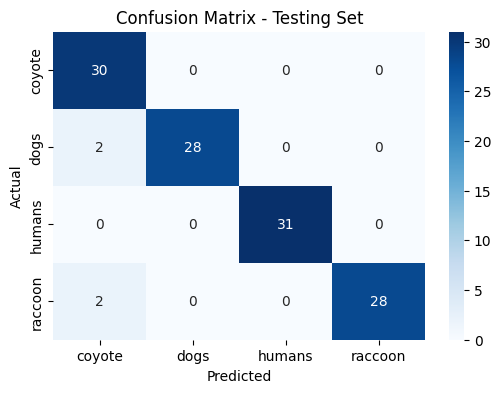

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from ultralytics import YOLO
import os

# 1. Train the final model (Using best parameters found: e.g., lr0=0.01)
print("--- Training Final Model ---")
final_model = YOLO('yolo11n-cls.pt')
final_results = final_model.train(
    data=WORK_DIR,
    epochs=FINAL_EPOCHS,
    lr0=0.01,
    imgsz=IMG_SIZE,
    batch=BATCH,
    project=RUNS_DIR,
    name='final_model',
    device=0
)

# Load the best weights from the final run
best_final_model = YOLO(os.path.join(RUNS_DIR, 'final_model', 'weights', 'best.pt'))

def evaluate_and_plot(model, X, y_true, dataset_name):
    print(f"\n--- Evaluating on {dataset_name} Set ---")
    preds = model.predict(X, verbose=False)
    y_pred = [model.names[p.probs.top1] for p in preds]

    print(f"\nClassification Report ({dataset_name}):")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'Confusion Matrix - {dataset_name} Set')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 2. Evaluate on Training Set
evaluate_and_plot(best_final_model, X_train, y_train, "Training")

# 3. Evaluate on Testing Set
evaluate_and_plot(best_final_model, X_test, y_test, "Testing")


MODEL 2 -> SVM HOG FEATURE EXTRACTION

In [ ]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score
)
import itertools

np.random.seed(42)

In [ ]:
DATA_DIR = Path("/content/drive/MyDrive/CS471_AI/cs471_data/")

labels_dict = {'humans': 0, 'dogs': 1, 'coyote': 2, 'raccoon': 3}
inv_labels = {v: k for k, v in labels_dict.items()}
class_names = [k for k, _ in sorted(labels_dict.items(), key=lambda kv: kv[1])]
number_of_classes = len(labels_dict)


image_data = []
labels = []
all_paths = []

for folder_dir in DATA_DIR.iterdir():
    if not folder_dir.is_dir():
        continue
    label_name = folder_dir.name
    if label_name not in labels_dict:
        print(f"Skipping unknown folder: {label_name}")
        continue

    # Balance the dataset by taking only the first 200 images per class
    image_paths = list(folder_dir.glob("*.jpg"))[:200]
    for img_path in image_paths:
        img = image.load_img(img_path, target_size=(100, 100))
        img_array = image.img_to_array(img)
        image_data.append(img_array)
        labels.append(labels_dict[label_name])
        all_paths.append(img_path)

image_data = np.array(image_data, dtype='float32') / 255.0
labels = np.array(labels)
all_paths = np.array(all_paths)

print(f"Loaded {len(image_data)} images across {number_of_classes} classes")
print("image_data:", image_data.shape, "labels:", labels.shape)

Loaded 800 images across 4 classes
image_data: (800, 100, 100, 3) labels: (800,)


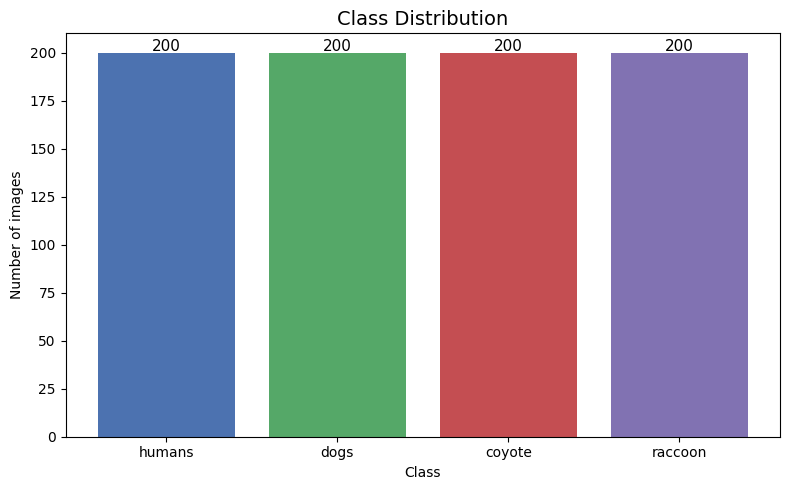

Total images:        800
Class counts:        {'humans': np.int64(200), 'dogs': np.int64(200), 'coyote': np.int64(200), 'raccoon': np.int64(200)}
Imbalance ratio:     1.00


In [ ]:
class_counts = np.bincount(labels, minlength=number_of_classes)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(class_names, class_counts,
              color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
ax.set_title('Class Distribution', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
for bar, cnt in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print(f"Total images:        {class_counts.sum()}")
print(f"Class counts:        {dict(zip(class_names, class_counts))}")
print(f"Imbalance ratio:     {class_counts.max() / class_counts.min():.2f}")

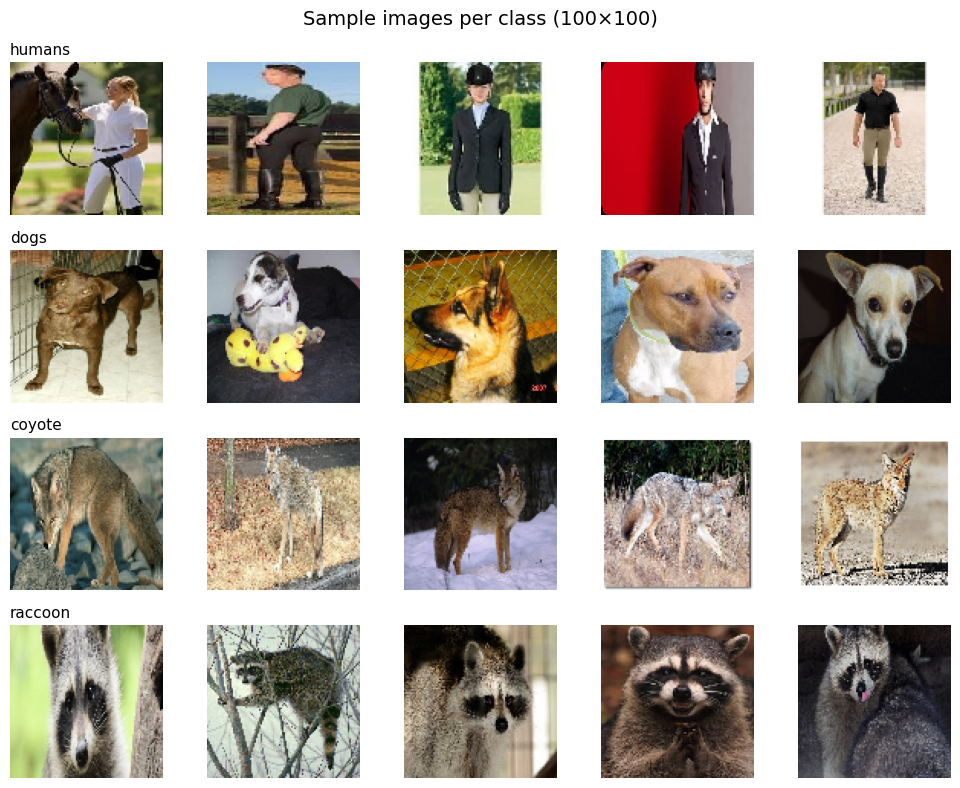

In [ ]:
n_per_class = 5
fig, axes = plt.subplots(number_of_classes, n_per_class,
                         figsize=(n_per_class * 2, number_of_classes * 2))
for class_idx in range(number_of_classes):
    idxs = np.where(labels == class_idx)[0][:n_per_class]
    for col, idx in enumerate(idxs):
        axes[class_idx, col].imshow(image_data[idx])
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(inv_labels[class_idx],
                                           loc='left', fontsize=11)
plt.suptitle('Sample images per class (100×100)', fontsize=14)
plt.tight_layout()
plt.show()

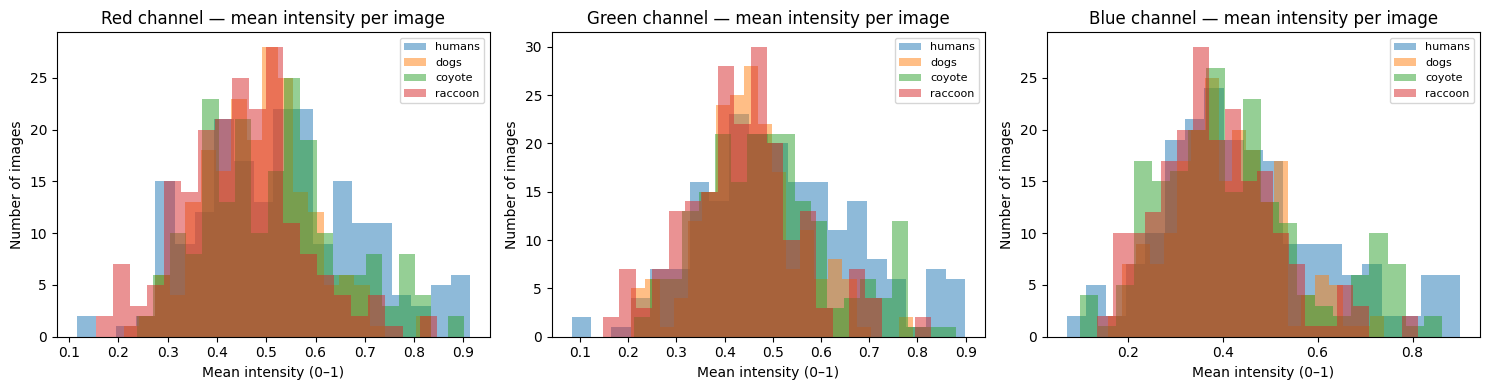

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ['Red', 'Green', 'Blue']
for ch in range(3):
    for class_idx in range(number_of_classes):
        class_imgs = image_data[labels == class_idx]
        mean_per_img = class_imgs[:, :, :, ch].mean(axis=(1, 2))
        axes[ch].hist(mean_per_img, bins=20, alpha=0.5,
                      label=inv_labels[class_idx])
    axes[ch].set_title(f'{channel_names[ch]} channel — mean intensity per image')
    axes[ch].set_xlabel('Mean intensity (0–1)')
    axes[ch].set_ylabel('Number of images')
    axes[ch].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# Stratified splitting
indices = np.arange(len(image_data))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices, labels,
    test_size=0.30, random_state=42, stratify=labels
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp,
    test_size=0.50, random_state=42, stratify=y_temp
)

# Keep the original image tensors for HOG feature extraction.
X_train_images = image_data[idx_train].copy()
X_val_images   = image_data[idx_val].copy()
X_test_images  = image_data[idx_test].copy()


total = len(image_data)
print(f"Train: {len(idx_train)} ({len(idx_train)/total*100:.1f}%)")
print(f"Val:   {len(idx_val)} ({len(idx_val)/total*100:.1f}%)")
print(f"Test:  {len(idx_test)} ({len(idx_test)/total*100:.1f}%)")

print("\nClass distribution per split:")
print("  train:", np.bincount(y_train, minlength=number_of_classes))
print("  val:  ", np.bincount(y_val,   minlength=number_of_classes))
print("  test: ", np.bincount(y_test,  minlength=number_of_classes))


Train: 560 (70.0%)
Val:   120 (15.0%)
Test:  120 (15.0%)

Class distribution per split:
  train: [140 140 140 140]
  val:   [30 30 30 30]
  test:  [30 30 30 30]


In [ ]:
class SVM:
    def __init__(self, C=1.0):
        self.C = C
        self.W = 0
        self.b = 0

    def fit(self, X, Y, batch_size=50, learning_rate=0.001, maxItr=500):
        no_of_features = X.shape[1]
        no_of_samples  = X.shape[0]
        n = learning_rate
        c = self.C

        W = np.zeros((1, no_of_features))
        bias = 0

        for itr in range(maxItr):
            ids = np.arange(no_of_samples)
            np.random.shuffle(ids)

            for batch_start in range(0, no_of_samples, batch_size):
                gradw = 0
                gradb = 0
                for j in range(batch_start, batch_start + batch_size):
                    if j < no_of_samples:
                        i = ids[j]
                        ti = Y[i] * (np.dot(W, X[i].T) + bias)
                        if ti <= 1:
                            gradw += c * Y[i] * X[i]
                            gradb += c * Y[i]
                W = W - n * W + n * gradw
                bias = bias + n * gradb

        self.W = W
        self.b = bias
        return W, bias


In [ ]:
#one vs one helpers
def getDataPairForSVM(d1, d2):
    l1, l2 = d1.shape[0], d2.shape[0]
    samples = l1 + l2
    features = d1.shape[1]
    data_pair = np.zeros((samples, features))
    data_labels = np.zeros((samples,))
    data_pair[:l1, :] = d1
    data_pair[l1:, :] = d2
    data_labels[:l1] = -1
    data_labels[l1:] = 1
    return data_pair, data_labels


def binaryPredict(x, w, b):
    z = np.dot(x, w.T) + b
    return 1 if z >= 0 else -1


def trainSVMs(x, y, C=1.0, learning_rate=1e-5, maxItr=100):
    data = {i: [] for i in range(number_of_classes)}
    for k in range(x.shape[0]):
        data[y[k]].append(x[k])
    for k in data:
        data[k] = np.array(data[k])

    svm_classifiers = {}
    for i in range(number_of_classes):
        svm_classifiers[i] = {}
        for j in range(i + 1, number_of_classes):
            xpair, ypair = getDataPairForSVM(data[i], data[j])
            clf = SVM(C=C)
            wts, b = clf.fit(xpair, ypair,
                                 learning_rate=learning_rate, maxItr=maxItr)
            svm_classifiers[i][j] = (wts, b)
    return svm_classifiers


def predict(x, svm_classifiers):
    count = np.zeros((number_of_classes,))
    for i in range(number_of_classes):
        for j in range(i + 1, number_of_classes):
            w, b = svm_classifiers[i][j]
            z = binaryPredict(x, w, b)
            if z == 1:
                count[j] += 1
            else:
                count[i] += 1
    return np.argmax(count)


def svm_accuracy(x, y, svm_classifiers):
    pred = []
    correct = 0
    for i in range(x.shape[0]):
        p = predict(x[i], svm_classifiers)
        pred.append(p)
        if p == y[i]:
            correct += 1
    return correct / x.shape[0], np.array(pred)

In [ ]:

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

In [ ]:
from skimage.feature import hog
from PIL import Image, ImageEnhance

# HOG-specific image splits.
# Split first, then augment training images only.
# Validation and test stay as untouched original images to avoid leakage.
X_train_images_hog = X_train_images.copy()
X_val_images_hog   = X_val_images.copy()
X_test_images_hog  = X_test_images.copy()

y_train_images_hog = y_train.copy()
y_val_hog          = y_val.copy()
y_test_hog         = y_test.copy()


def augment_one_image(img, rng):
    """Return one realistic augmented RGB image in float32 range [0, 1]."""
    img_uint8 = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    pil_img = Image.fromarray(img_uint8)

    transpose = getattr(Image, "Transpose", Image)
    resampling = getattr(Image, "Resampling", Image)

    # Horizontal flip
    if rng.random() < 0.5:
        pil_img = pil_img.transpose(transpose.FLIP_LEFT_RIGHT)

    # Small rotation, using the image's average color as the border fill
    angle = float(rng.uniform(-15, 15))
    fill_color = tuple(img_uint8.mean(axis=(0, 1)).astype(np.uint8).tolist())
    pil_img = pil_img.rotate(
        angle,
        resample=resampling.BILINEAR,
        fillcolor=fill_color
    )

    # Slight brightness and contrast shifts
    brightness_factor = float(rng.uniform(0.85, 1.15))
    contrast_factor   = float(rng.uniform(0.85, 1.15))
    pil_img = ImageEnhance.Brightness(pil_img).enhance(brightness_factor)
    pil_img = ImageEnhance.Contrast(pil_img).enhance(contrast_factor)

    return np.asarray(pil_img, dtype=np.float32) / 255.0


def augment_training_images_to_target_per_class(
    X_images,
    y_labels,
    target_per_class=500,
    random_state=42
):
    """Create a balanced HOG training image set with target_per_class images per class."""
    rng = np.random.default_rng(random_state)
    X_augmented_parts = []
    y_augmented_parts = []

    for class_idx in range(number_of_classes):
        class_images = X_images[y_labels == class_idx]
        current_count = len(class_images)

        if current_count == 0:
            print(f"Warning: class {class_idx} has no training images.")
            continue

        if current_count >= target_per_class:
            chosen = rng.choice(current_count, size=target_per_class, replace=False)
            class_output = class_images[chosen].copy()
        else:
            class_output = [img.copy() for img in class_images]
            needed = target_per_class - current_count

            for _ in range(needed):
                source_img = class_images[rng.integers(0, current_count)]
                class_output.append(augment_one_image(source_img, rng))

            class_output = np.asarray(class_output, dtype=np.float32)

        X_augmented_parts.append(class_output)
        y_augmented_parts.append(
            np.full(len(class_output), class_idx, dtype=y_labels.dtype)
        )

    X_augmented = np.concatenate(X_augmented_parts, axis=0)
    y_augmented = np.concatenate(y_augmented_parts, axis=0)

    shuffle_idx = rng.permutation(len(y_augmented))
    return X_augmented[shuffle_idx], y_augmented[shuffle_idx]


def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False,
            channel_axis=-1
        )
        hog_features.append(features)
    return np.array(hog_features, dtype=np.float32)


HOG_TARGET_PER_CLASS = 500

print("Augmenting HOG training images only...")
X_train_images_hog_aug, y_train_hog = augment_training_images_to_target_per_class(
    X_train_images_hog,
    y_train_images_hog,
    target_per_class=HOG_TARGET_PER_CLASS,
    random_state=42
)

print("HOG training image counts after augmentation:")
print(np.bincount(y_train_hog, minlength=number_of_classes))
print("HOG validation image counts, unchanged:")
print(np.bincount(y_val_hog, minlength=number_of_classes))
print("HOG test image counts, unchanged:")
print(np.bincount(y_test_hog, minlength=number_of_classes))

print("\nExtracting HOG features...")
X_train_hog = extract_hog_features(X_train_images_hog_aug)
X_val_hog   = extract_hog_features(X_val_images_hog)
X_test_hog  = extract_hog_features(X_test_images_hog)

print(f"HOG train shape after augmentation: {X_train_hog.shape}")
print(f"HOG val shape:                      {X_val_hog.shape}")
print(f"HOG test shape:                     {X_test_hog.shape}")

Augmenting HOG training images only...
HOG training image counts after augmentation:
[500 500 500 500]
HOG validation image counts, unchanged:
[30 30 30 30]
HOG test image counts, unchanged:
[30 30 30 30]

Extracting HOG features...
HOG train shape after augmentation: (2000, 4356)
HOG val shape:                      (120, 4356)
HOG test shape:                     (120, 4356)


In [ ]:
# HOG + SVM: Tune C
#tune c reg and maxItr
C_values_hog = [0.01, 0.1, 1.0,]
c_results_hog = []

# Fixed learning rate while tuning C.
# The learning rate gets tuned separately in the next HOG tuning step.
hog_lr_for_c_tuning = 1e-5

print(f"Tuning HOG SVM C (learning_rate={hog_lr_for_c_tuning}, maxItr=300)")
for C in C_values_hog:
    hog_clfs = trainSVMs(
        X_train_hog,
        y_train_hog,
        C=C,
        learning_rate=hog_lr_for_c_tuning,
        maxItr=200
    )

    train_acc, _ = svm_accuracy(X_train_hog, y_train_hog, hog_clfs)
    val_acc, _   = svm_accuracy(X_val_hog,   y_val_hog,   hog_clfs)

    c_results_hog.append((C, train_acc, val_acc))
    print(f"  C={C:<7} train={train_acc:.4f}  val={val_acc:.4f}")

best_C_hog = max(c_results_hog, key=lambda r: r[2])[0]
print(f"\n>> Best HOG C on validation: {best_C_hog}")

Tuning HOG SVM C (learning_rate=1e-05, maxItr=300)
  C=0.01    train=0.2575  val=0.2500
  C=0.1     train=0.2575  val=0.2500
  C=1.0     train=0.6045  val=0.4917

>> Best HOG C on validation: 1.0


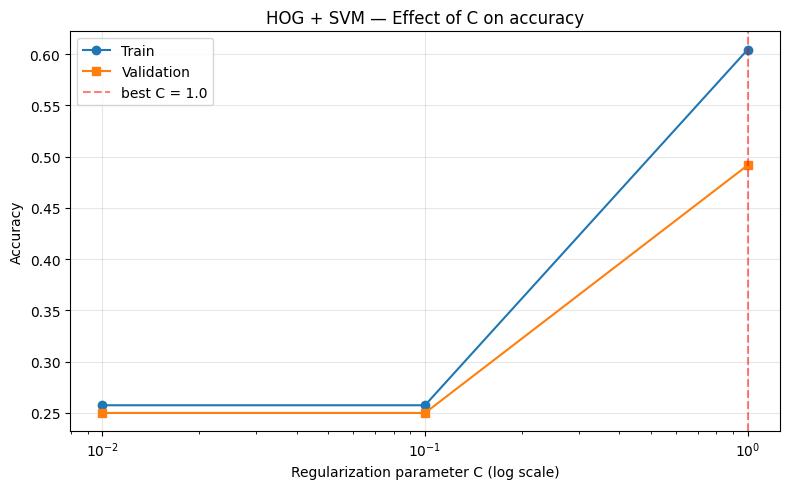

In [ ]:
# Plot: HOG validation accuracy vs C
Cs_hog        = [r[0] for r in c_results_hog]
train_acc_hog = [r[1] for r in c_results_hog]
val_acc_hog   = [r[2] for r in c_results_hog]

plt.figure(figsize=(8, 5))
plt.semilogx(Cs_hog, train_acc_hog, 'o-', label='Train')
plt.semilogx(Cs_hog, val_acc_hog,   's-', label='Validation')
plt.axvline(best_C_hog, color='red', linestyle='--', alpha=0.5,
            label=f'best C = {best_C_hog}')
plt.xlabel('Regularization parameter C (log scale)')
plt.ylabel('Accuracy')
plt.title('HOG + SVM — Effect of C on accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# HOG + SVM: Tune learning rate
lr_values_hog = [1e-6, 1e-5, 0.0001]
lr_results_hog = []

print(f"Tuning HOG SVM learning_rate (C={best_C_hog}, maxItr=300)")
for lr in lr_values_hog:
    hog_clfs = trainSVMs(
        X_train_hog,
        y_train_hog,
        C=best_C_hog,
        learning_rate=lr,
        maxItr=200
    )

    train_acc, _ = svm_accuracy(X_train_hog, y_train_hog, hog_clfs)
    val_acc, _   = svm_accuracy(X_val_hog,   y_val_hog,   hog_clfs)

    lr_results_hog.append((lr, train_acc, val_acc))
    print(f"  lr={lr:<8} train={train_acc:.4f}  val={val_acc:.4f}")

best_lr_hog = max(lr_results_hog, key=lambda r: r[2])[0]

print(f"\n>> Best HOG learning rate on validation: {best_lr_hog}")
print(f">> Final HOG SVM hyperparameters: C={best_C_hog}, learning_rate={best_lr_hog}")

Tuning HOG SVM learning_rate (C=1.0, maxItr=300)
  lr=1e-06    train=0.2575  val=0.2500
  lr=1e-05    train=0.6030  val=0.4917
  lr=0.0001   train=0.8575  val=0.5583

>> Best HOG learning rate on validation: 0.0001
>> Final HOG SVM hyperparameters: C=1.0, learning_rate=0.0001


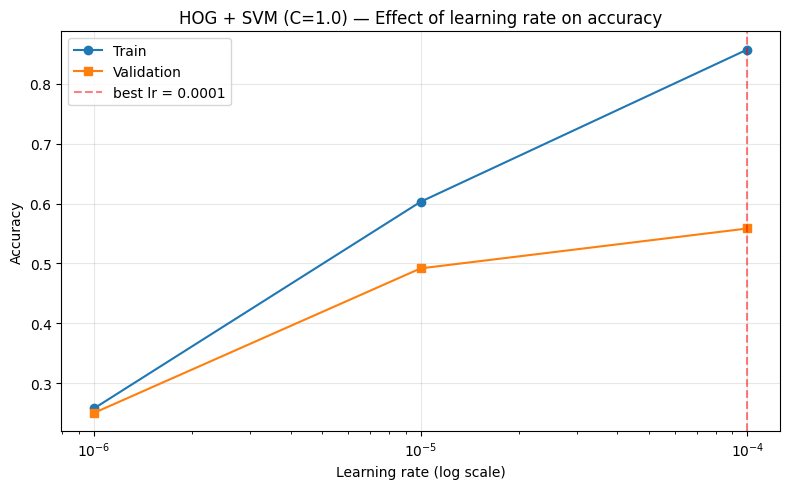

In [ ]:
# Sort results by learning rate so the line plot connects points left-to-right
sorted_lr_results = sorted(lr_results_hog, key=lambda x: x[0])

# Plot: HOG validation accuracy vs learning rate
lrs_hog       = [r[0] for r in sorted_lr_results]
train_acc_hog = [r[1] for r in sorted_lr_results]
val_acc_hog   = [r[2] for r in sorted_lr_results]

plt.figure(figsize=(8, 5))
plt.semilogx(lrs_hog, train_acc_hog, 'o-', label='Train')
plt.semilogx(lrs_hog, val_acc_hog,   's-', label='Validation')
plt.axvline(best_lr_hog, color='red', linestyle='--', alpha=0.5,
            label=f'best lr = {best_lr_hog}')
plt.xlabel('Learning rate (log scale)')
plt.ylabel('Accuracy')
plt.title(f'HOG + SVM (C={best_C_hog}) — Effect of learning rate on accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Training final HOG SVM on augmented HOG training split only (C=1.0, lr=0.0001)...

SVM (HOG Tuned + Train Augmentation) — train accuracy: 0.8595
SVM (HOG Tuned + Train Augmentation) — val accuracy:   0.5667
SVM (HOG Tuned + Train Augmentation) — test accuracy:  0.6250
SVM (HOG Tuned + Train Augmentation) — test macro F1:  0.6229

Classification output (HOG Tuned + Train Augmentation, test set only):
              precision    recall  f1-score   support

      humans     0.7273    0.8000    0.7619        30
        dogs     0.6250    0.5000    0.5556        30
      coyote     0.5135    0.6333    0.5672        30
     raccoon     0.6538    0.5667    0.6071        30

    accuracy                         0.6250       120
   macro avg     0.6299    0.6250    0.6229       120
weighted avg     0.6299    0.6250    0.6229       120



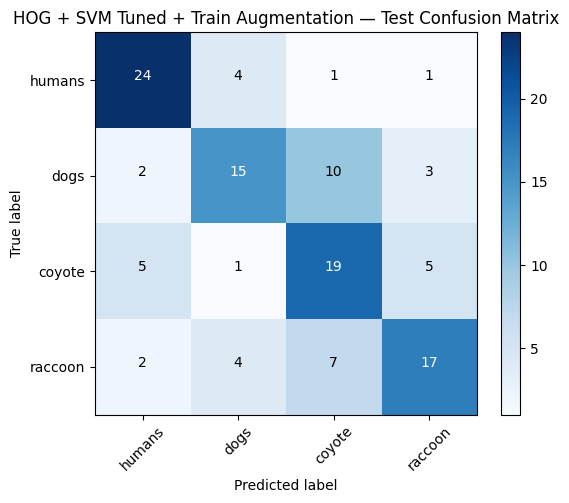

In [ ]:
print(f"\nTraining final HOG SVM on augmented HOG training split only (C={best_C_hog}, lr={best_lr_hog})...")
best_svm_hog = trainSVMs(
    X_train_hog,
    y_train_hog,
    C=best_C_hog,
    learning_rate=best_lr_hog,
    maxItr=200
)

train_acc_hog_tuned, y_train_pred_hog_tuned = svm_accuracy(
    X_train_hog,
    y_train_hog,
    best_svm_hog
)
val_acc_hog_tuned, y_val_pred_hog_tuned = svm_accuracy(
    X_val_hog,
    y_val_hog,
    best_svm_hog
)
test_acc_hog_tuned, y_test_pred_hog_tuned = svm_accuracy(
    X_test_hog,
    y_test_hog,
    best_svm_hog
)
test_f1_hog_tuned = f1_score(
    y_test_hog,
    y_test_pred_hog_tuned,
    average='macro'
)

print(f"\nSVM (HOG Tuned + Train Augmentation) — train accuracy: {train_acc_hog_tuned:.4f}")
print(f"SVM (HOG Tuned + Train Augmentation) — val accuracy:   {val_acc_hog_tuned:.4f}")
print(f"SVM (HOG Tuned + Train Augmentation) — test accuracy:  {test_acc_hog_tuned:.4f}")
print(f"SVM (HOG Tuned + Train Augmentation) — test macro F1:  {test_f1_hog_tuned:.4f}\n")

print("Classification output (HOG Tuned + Train Augmentation, test set only):")
print(classification_report(
    y_test_hog,
    y_test_pred_hog_tuned,
    target_names=class_names,
    digits=4
))

cnf_hog_tuned = confusion_matrix(y_test_hog, y_test_pred_hog_tuned)
plt.figure(figsize=(6, 5))
plot_confusion_matrix(
    cnf_hog_tuned,
    class_names,
    title='HOG + SVM Tuned + Train Augmentation — Test Confusion Matrix'
)
plt.show()


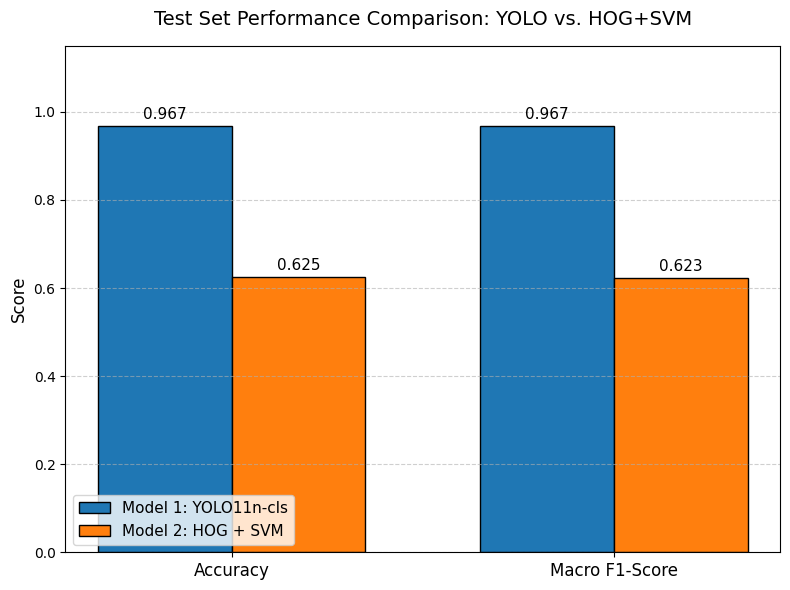

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# 1. Retrieve YOLO (Model 1) Metrics
# Reconstruct original string labels for YOLO from the file paths in X_test
yolo_y_test = [path.split('/')[-2] for path in X_test]

# Run quick inference to get exact test predictions for the final YOLO model
yolo_preds = best_final_model.predict(X_test, verbose=False)
yolo_y_pred = [best_final_model.names[p.probs.top1] for p in yolo_preds]

yolo_acc = accuracy_score(yolo_y_test, yolo_y_pred)
yolo_f1 = f1_score(yolo_y_test, yolo_y_pred, average='macro')

# 2. Retrieve HOG + SVM (Model 2) Metrics
# These were already calculated and stored in variables
svm_acc = test_acc_hog_tuned
svm_f1 = test_f1_hog_tuned

# 3. Create the Comparison Plot
labels = ['Accuracy', 'Macro F1-Score']
yolo_scores = [yolo_acc, yolo_f1]
svm_scores = [svm_acc, svm_f1]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, yolo_scores, width, label='Model 1: YOLO11n-cls', color='#1f77b4', edgecolor='black')
rects2 = ax.bar(x + width/2, svm_scores, width, label='Model 2: HOG + SVM', color='#ff7f0e', edgecolor='black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Test Set Performance Comparison: YOLO vs. HOG+SVM', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.15)  # Make room for the labels above the bars
ax.legend(loc='lower left', fontsize=11)

# Attach a text label above each bar displaying its height
ax.bar_label(rects1, fmt='%.3f', padding=3, fontsize=11)
ax.bar_label(rects2, fmt='%.3f', padding=3, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()